In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neural_network import MLPClassifier, MLPRegressor

from numpy.random import uniform as unif
from numpy.random import choice

import os 
import sys

sys.path.append("./../../")
from utils import *
from utils_data import *

In [4]:
np.random.seed(42)

n_rct = 10000
n_obs = 10000
n_rct_val = 500
n_obs_val = 500

d = 1

meas_covs = [f"X{i + 1}" for i in range(d)]
unmeas_covs = [f"U{i + 1}" for i in range(d)]

all_covs = meas_covs + unmeas_covs
adjust_covs = all_covs
adjust_covs = meas_covs

num_trials = 10
biases = {"avg": [], "X<0": [], "X>0": []}
covariances = {"val1": {"SE_Y0": [], "SE_Y1": [], "SE_A": [], "SE_S": []},
               "val2": {"SE_Y0": [], "SE_Y1": [], "SE_A": [], "SE_S": []},}


for _ in range(num_trials):
    cov = sample_cov_matrix(2)
    px_dist = "unif"

    df_rct = init_df(n_rct, d, r=1, px_dist=px_dist, mean=[0,0], cov=cov)
    df_obs = init_df(n_obs, d, r=0, px_dist=px_dist, mean=[0,0], cov=cov)
    df_rct_val = init_df(n_rct_val, d, r=1, px_dist=px_dist, mean=[0,0], cov=cov)
    df_obs_val = init_df(n_obs_val, d, r=0, px_dist=px_dist, mean=[0,0], cov=cov)

    # unif(1, 2, 2 * d + 1) * choice([-1,1], 2 * d + 1),
    
    rct_legendre_coefs = {"Y0": [0, 0, 0],
                        "Y1": [0, 1, 1],
                        "A": None,
                        "S": None,} 

    obs_legendre_coefs = {"Y0": rct_legendre_coefs["Y0"],
                        "Y1": rct_legendre_coefs["Y1"],
                        "A": [0, 1, 1],
                        "S": None,}

    random_probs = {"Y0": 0.5, "Y1": 0.5, "A": 0.5, "S": 0.95}

    # generate data and fit estimators

    sample_TOS(df_rct, all_covs, rct_legendre_coefs, random_probs)
    sample_TOS(df_obs, all_covs, obs_legendre_coefs, random_probs)
    sample_TOS(df_rct_val, all_covs, rct_legendre_coefs, random_probs)
    sample_TOS(df_obs_val, all_covs, obs_legendre_coefs, random_probs)

    rct_models = fit_all_models(df_rct, adjust_covs)
    log_model_preds(df_rct, adjust_covs, rct_models)
    log_model_preds(df_rct_val, adjust_covs, rct_models)

    
    obs_models = fit_all_models(df_obs, adjust_covs)
    log_model_preds(df_obs, adjust_covs, obs_models)
    log_model_preds(df_obs_val, adjust_covs, obs_models)

    df_merged, pr_model = merge_df_train(df_rct, df_obs, adjust_covs)
    df_merged_val = merge_df_val(df_rct_val, df_obs_val, adjust_covs,  
                                    pr_model, rct_models, obs_models, df_merged)
    

    for key in covariances["val1"]:
        m, p, _, _ = pearsonr_ci(df_merged_val, "w1(X)", key)
        covariances["val1"][key].append((m,p))

        m, p, _, _ = pearsonr_ci(df_merged_val, "w2(X)", key)
        covariances["val2"][key].append((m,p))

In [ ]:
plt.figure()
plt.scatter(df_merged_val["X1"], df_merged_val["w1(X)"], color='blue', s=10)
plt.xlabel("X")
plt.ylabel("w1(X)")
plt.grid(True)
plt.show()

plt.figure()
plt.scatter(df_merged_val["X1"], df_merged_val["w2(X)"], color='blue', s=10)
plt.xlabel("X")
plt.ylabel("w2(X)")
plt.grid(True)
plt.show()

plt.figure()
plt.scatter(df_merged_val["X1"], df_merged_val["SE_Y0"], color='blue', s=2)
plt.xlabel("X")
plt.ylabel("SE_Y0")
plt.grid(True)
plt.show()

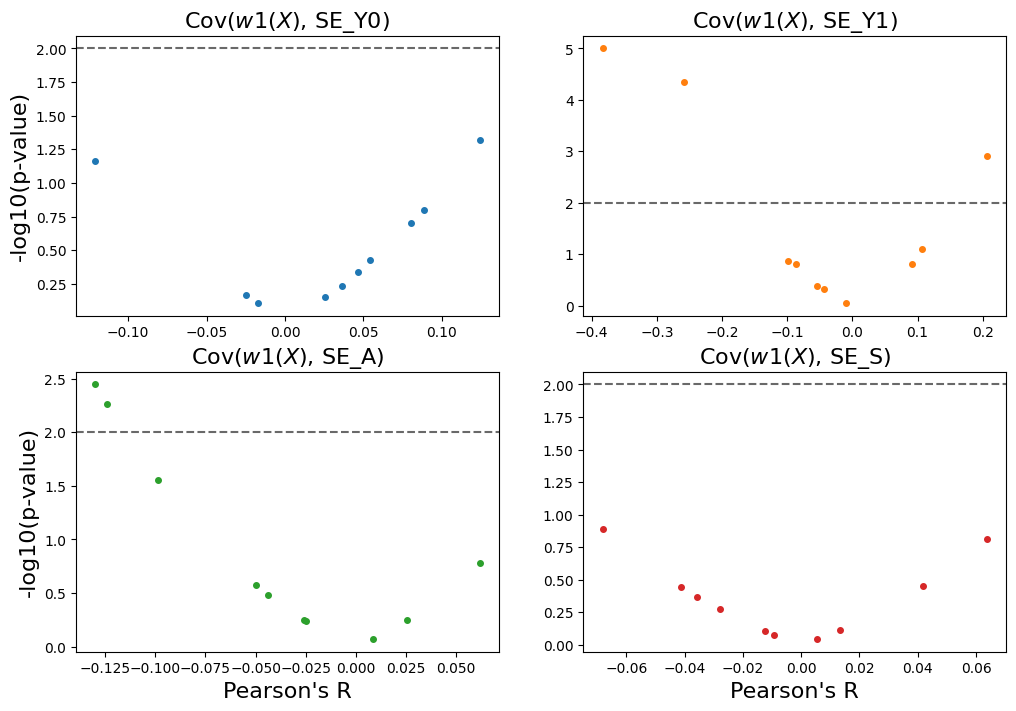

In [6]:
cp = sns.color_palette("tab10")
fig, axs = plt.subplots(2, 2, figsize=(12,8)) 

for idx, key in enumerate(covariances["val1"]):
    i = idx // 2
    j = idx % 2

    axs[i, j].set_title(f"Cov($w1(X)$, {key})", fontsize=16)
    axs[i, j].axhline(y=-np.log10(0.01), color='dimgray', linestyle='--', label='p = 0.05')
    
    arr = np.array(covariances["val1"][key])
    hat_cov = arr[:, 0]
    log_p_val = np.clip(-np.log10(arr[:, 1]), a_min=None, a_max=5)
    axs[i, j].scatter(hat_cov, log_p_val, color=cp[idx], s=16, alpha=1)

axs[0,0].set_ylabel('-log10(p-value)', fontsize=16)
axs[1,0].set_ylabel('-log10(p-value)', fontsize=16)
axs[1,0].set_xlabel("Pearson's R", fontsize=16)
axs[1,1].set_xlabel("Pearson's R", fontsize=16)

plt.show()

In [ ]:
cp = sns.color_palette("tab10")
fig, axs = plt.subplots(2, 3, figsize=(20,10)) 

for idx, key in enumerate(covariances["val1"]):
    i = idx // 3 
    j = idx % 3

    axs[i, j].set_title(f"Cov($w2(X)$, {key})", fontsize=16)
    axs[i, j].axhline(y=-np.log10(0.01), color='dimgray', linestyle='--', label='p = 0.05')
    
    arr = np.array(covariances["val2"][key])
    hat_cov = arr[:, 0]
    log_p_val = np.clip(-np.log10(arr[:, 1]), a_min=None, a_max=5)
    axs[i, j].scatter(hat_cov, log_p_val, color=cp[idx], s=16, alpha=1)

axs[0,0].set_ylabel('-log10(p-value)', fontsize=16)
axs[1,0].set_ylabel('-log10(p-value)', fontsize=16)
axs[1,1].set_xlabel("Pearson's R", fontsize=16)

plt.show()

In [ ]:
X = df_merged_val["X1"]
Y = df_merged_val["w2(X)"]

plt.scatter(X, Y, color='blue', s=2)
plt.xlabel("X")
plt.ylabel("w2(X)")
plt.grid(True)
plt.show()